# 04. Results Analysis

Loads the fitted models from `models/` (written by `03_train_final`) and summarizes them: the blend weights used, RSF and XGB feature importances, and the distribution of blended risk scores across the training cohort. It also computes SHAP values, but only if the `shap` package is installed.

This notebook is entirely new. The original single notebook had no comparison table or SHAP code to move over, so everything here is fresh, and it's kept deliberately light since it wasn't part of the original modeling logic.

In [3]:
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "liverrisk" / "features.py").exists():
            return p
    raise RuntimeError("Could not locate repo root (liverrisk/features.py not found)")


REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: c:\Users\paabl\OneDrive\Documents\GitHub\TFG_pabloCalderon


In [4]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

MODELS_DIR = REPO_ROOT / "models"
PROCESSED_DIR = REPO_ROOT / "liverrisk" / "data" / "processed"

blend_weights_hep = joblib.load(MODELS_DIR / "blend_weights_hep.joblib")
blend_weights_death = joblib.load(MODELS_DIR / "blend_weights_death.joblib")
train_scores_hep = joblib.load(MODELS_DIR / "train_scores_hepatic.joblib")
train_scores_death = joblib.load(MODELS_DIR / "train_scores_death.joblib")

print("Blend weights (w_cox, w_rsf, w_xgb):")
print("  hepatic:", blend_weights_hep)
print("  death  :", blend_weights_death)

Blend weights (w_cox, w_rsf, w_xgb):
  hepatic: [0.0, 1.0, 0.0]
  death  : [0.4, 0.4, 0.2]


## Training cohort blended risk score distributions

Plots histograms of the blended risk scores across the training cohort for each endpoint, giving a sense of how spread out the model's risk predictions are.

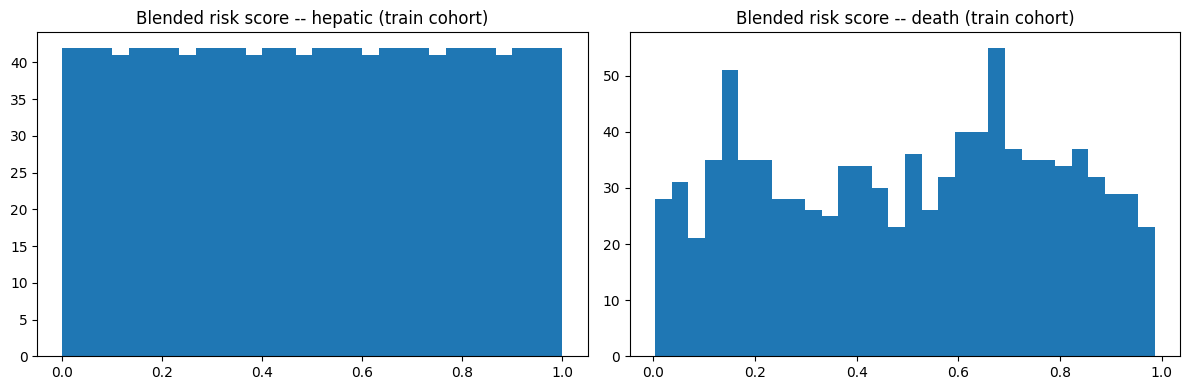

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_scores_hep, bins=30)
axes[0].set_title("Blended risk score -- hepatic (train cohort)")
axes[1].hist(train_scores_death, bins=30)
axes[1].set_title("Blended risk score -- death (train cohort)")
plt.tight_layout()
plt.show()

## SHAP (optional)

This section only runs if the `shap` package is installed. It wasn't a dependency of the original notebook, so it's skipped by default instead of failing the notebook when `shap` is missing. When it does run, it fits a `KernelExplainer` around the RSF hepatic model's predictions on a small background sample, since RandomSurvivalForest isn't supported by SHAP's faster TreeExplainer.

  0%|          | 0/20 [00:00<?, ?it/s]

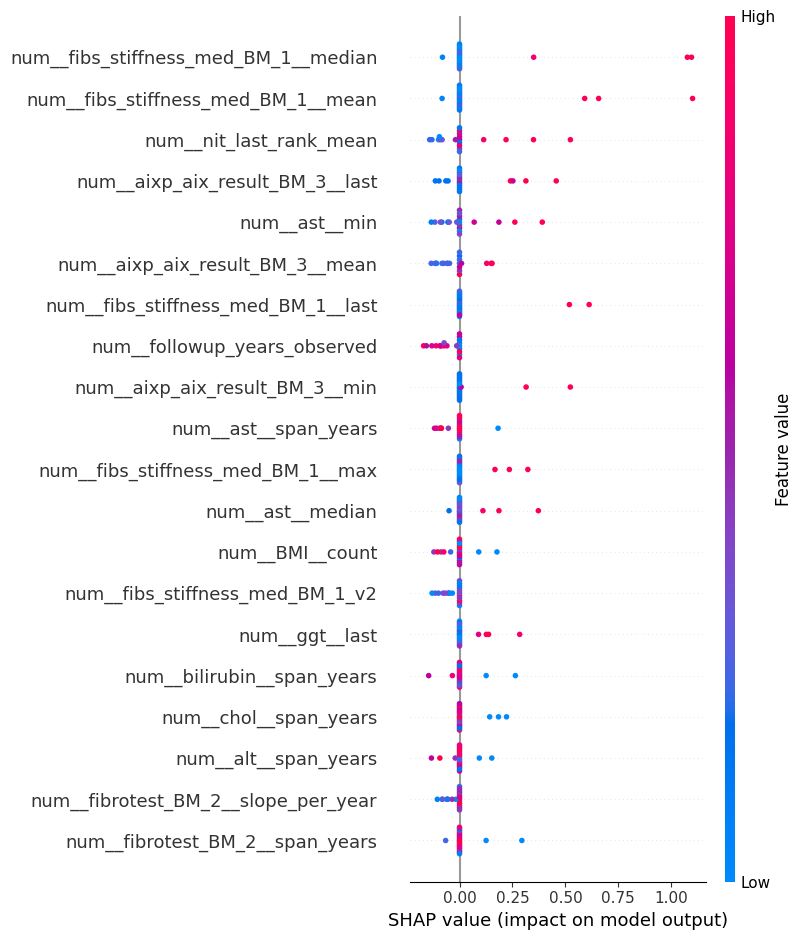

In [7]:
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("shap is not installed -- skipping. `pip install shap` to enable this cell.")

if HAS_SHAP:
    X_hep = pd.read_parquet(PROCESSED_DIR / "hep_X.parquet")
    X_hep_transformed = rsf_hep.named_steps["pre"].transform(X_hep)

    # RandomSurvivalForest isn't supported by TreeExplainer (confirmed:
    # InvalidModelError). KernelExplainer works with ANY model, since it
    # only calls .predict() -- it doesn't need to understand the model's
    # internal structure at all. Slower, so we use a small background
    # sample and a small number of patients to explain.
    N_BACKGROUND = 30   # reference patients KernelExplainer compares against
    N_EXPLAIN = 20       # patients we actually compute SHAP values for

    # shap needs a plain function: features in, one prediction number out.
    def rsf_predict(X):
        return rsf_hep.named_steps["rsf"].predict(X)

    # A small random background sample, not the full 1253 -- KernelExplainer's
    # cost scales with this size, so keep it small.
    background = shap.sample(X_hep_transformed, N_BACKGROUND, random_state=27)

    explainer = shap.KernelExplainer(rsf_predict, background)

    # Explain just a handful of patients -- this is genuinely slow per patient.
    X_to_explain = X_hep_transformed[:N_EXPLAIN]
    shap_values = explainer.shap_values(X_to_explain)

    shap.summary_plot(shap_values, X_to_explain, feature_names=feature_names, show=True)

## Behind the Scenes page assets

Precomputes everything the webapp's "Behind the Scenes" tab displays: the GET /about response plus four static PNGs covering permutation importance charts, Kaplan-Meier curves, and dataset stats. All the computation and chart drawing happens here, so the webapp only needs to read `about_stats.json` back and serve the PNGs as static files. No chart building code runs client side.

In [7]:
import re

from sklearn.inspection import permutation_importance
from sksurv.metrics import concordance_index_censored
from sksurv.nonparametric import kaplan_meier_estimator

from liverrisk.features import load_features, prepare_survival_target

cox_hep = joblib.load(MODELS_DIR / "cox_hep.joblib")
rsf_hep = joblib.load(MODELS_DIR / "rsf_hep.joblib")
xgb_hep = joblib.load(MODELS_DIR / "xgb_hep.joblib")
cox_death = joblib.load(MODELS_DIR / "cox_death.joblib")
rsf_death = joblib.load(MODELS_DIR / "rsf_death.joblib")
xgb_death = joblib.load(MODELS_DIR / "xgb_death.joblib")

X_HEP, y_hep, HEP_EVENT, HEP_TIME = load_features("hep", PROCESSED_DIR)
X_DEATH, y_death, DEATH_EVENT, DEATH_TIME = load_features("death", PROCESSED_DIR)

IMAGES_DIR = REPO_ROOT / "liverrisk-webapp" / "frontend" / "images"
PRECOMPUTED_DIR = REPO_ROOT / "liverrisk-webapp" / "backend" / "precomputed"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
PRECOMPUTED_DIR.mkdir(parents=True, exist_ok=True)

# Site palette, so the saved PNGs blend into the page instead of looking
# like a pasted-in chart.
ACCENT = "#1f6f5c"
INK = "#14293d"
GRID = "#e5e5e5"
plt.rcParams.update({
    "font.family": "Georgia",
    "axes.edgecolor": "#c9c9c9",
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": "#444444",
    "ytick.color": "#444444",
    "figure.facecolor": "none",
    "axes.facecolor": "none",
    "savefig.facecolor": "none",
})

print(f"X_HEP={X_HEP.shape}, X_DEATH={X_DEATH.shape}")


X_HEP=(1253, 255), X_DEATH=(984, 255)\n

### Permutation importance

`permutation_importance` expects a single fitted estimator with a `.predict(X)` method, but there isn't one model per endpoint here: hepatic and death are each a weighted blend of Coxnet, RSF, and XGBoost percentile ranks, the same blend that `models_loader.score_one_endpoint` uses in the webapp. The `BlendPredictor` class below wraps that blend behind a plain `.predict(X)` method so it slots into `permutation_importance` like any single model would. This also sidesteps the fact that RandomSurvivalForest has no `.feature_importances_` of its own, since that attribute is never touched.

Importance is scored with the C index (`concordance_index_censored`), the same metric the competition is judged on, and it's computed on a random 300 patient subsample of each training cohort purely for speed. Running 255 columns through 5 repeats and up to 3 sub models against the full 1000 plus rows was too slow for what's meant to be one illustrative chart rather than a full model evaluation.

`ADMIN_FEATURES` is excluded from the chart ranking only, not from the model itself. `followup_years_observed`, the number of years between a patient's first and last visit, is almost tautologically tied to the survival time target: patients followed longer are, simply by how censoring works, more likely to have been observed alive longer. It dominated the death chart by roughly 80 times over every clinically meaningful feature, which defeats the point of a top features chart.

In [8]:
class BlendPredictor:
    """predict() = each sub-model's prediction, turned into a percentile
    against its own fixed training-cohort scores, then weight-averaged --
    exactly what score_one_endpoint() does in the webapp backend."""

    def __init__(self, models, weights, train_raw_scores):
        self.models = models              # {"cox": ..., "rsf": ..., "xgb": ...}
        self.weights = weights            # (w_cox, w_rsf, w_xgb)
        self.train_raw_scores = train_raw_scores  # {"cox": array, ...} on the *unpermuted* training data

    def fit(self, X, y=None):
        return self  # already-fitted sub-models; nothing to do

    def predict(self, X):
        blended = np.zeros(len(X))
        weight_sum = sum(self.weights)
        for name, w in zip(["cox", "rsf", "xgb"], self.weights):
            if w == 0:
                continue  # e.g. hepatic's blend is pure RSF -- skip the other two entirely
            raw = self.models[name].predict(X)
            combined = np.concatenate([self.train_raw_scores[name], raw])
            pct = pd.Series(combined).rank(pct=True).to_numpy()[-len(raw):]
            blended += w * pct
        return blended / weight_sum


def cindex_scorer(estimator, X, y):
    preds = estimator.predict(X)
    event_name, time_name = y.dtype.names
    return concordance_index_censored(y[event_name], y[time_name], preds)[0]


def clean_feature_name(raw_name: str) -> str:
    """"ggt__span_years" -> "Ggt Span Years", light cleanup for chart labels."""
    name = re.sub(r"^(num|cat)__", "", raw_name)
    return name.replace("__", " ").replace("_", " ").strip().title()


ADMIN_FEATURES = {"followup_years_observed", "age_last_observed"}


def top_features(perm_result, columns, exclude=frozenset(), n=10):
    order = np.argsort(perm_result.importances_mean)[::-1]
    picked = []
    for i in order:
        if columns[i] in exclude:
            continue
        picked.append((columns[i], float(perm_result.importances_mean[i])))
        if len(picked) == n:
            break
    return picked


def plot_importance(pairs, title, out_path):
    pairs = list(reversed(pairs))  # largest bar at the top
    labels = [clean_feature_name(name) for name, _ in pairs]
    values = [val for _, val in pairs]

    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.barh(labels, values, color=ACCENT, height=0.6)
    ax.set_xlabel("Permutation importance (drop in C-index)")
    ax.set_title(title, fontsize=13, fontweight="bold", loc="left", color=INK)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, transparent=True)
    plt.show()


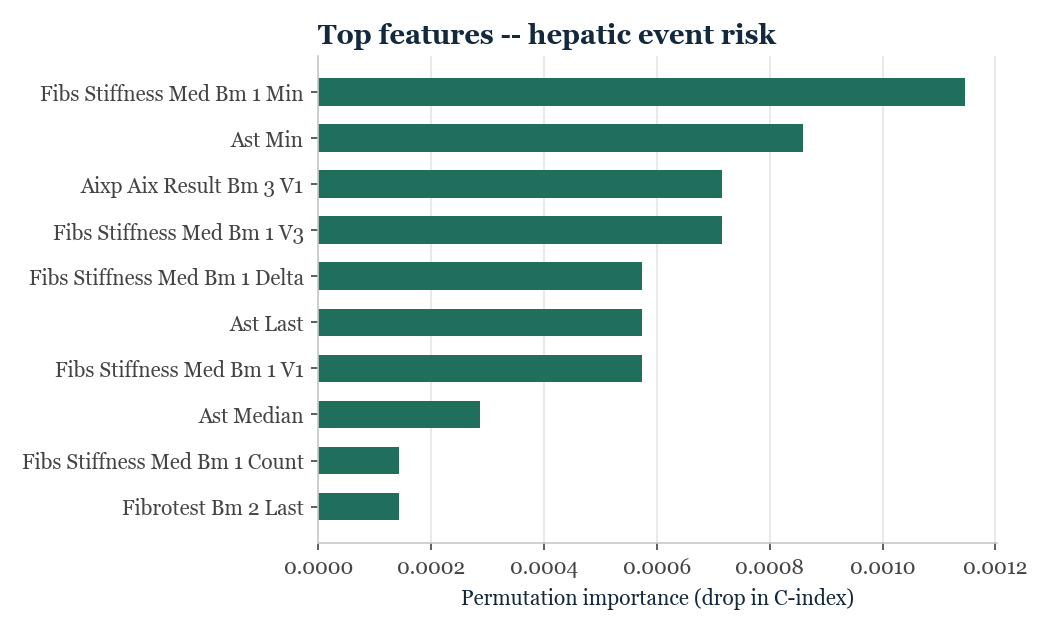

Top 5 hepatic: [('fibs_stiffness_med_BM_1__min', 0.0011461318051576353), ('ast__min', 0.0008595988538682153), ('aixp_aix_result_BM_3_v1', 0.0007163323782235498), ('fibs_stiffness_med_BM_1_v3', 0.0007163323782235498), ('fibs_stiffness_med_BM_1__delta', 0.0005730659025788398)]\n

In [9]:
hep_models = {"cox": cox_hep, "rsf": rsf_hep, "xgb": xgb_hep}
hep_train_raw = {name: m.predict(X_HEP) for name, m in hep_models.items()}
hep_blend = BlendPredictor(hep_models, blend_weights_hep, hep_train_raw)

death_models = {"cox": cox_death, "rsf": rsf_death, "xgb": xgb_death}
death_train_raw = {name: m.predict(X_DEATH) for name, m in death_models.items()}
death_blend = BlendPredictor(death_models, blend_weights_death, death_train_raw)

SAMPLE_SIZE = 300
rng = np.random.RandomState(27)
hep_sample_idx = rng.choice(len(X_HEP), size=min(SAMPLE_SIZE, len(X_HEP)), replace=False)
death_sample_idx = rng.choice(len(X_DEATH), size=min(SAMPLE_SIZE, len(X_DEATH)), replace=False)

perm_hep = permutation_importance(
    hep_blend, X_HEP.iloc[hep_sample_idx], y_hep[hep_sample_idx],
    scoring=cindex_scorer, n_repeats=5, random_state=27,
)
perm_death = permutation_importance(
    death_blend, X_DEATH.iloc[death_sample_idx], y_death[death_sample_idx],
    scoring=cindex_scorer, n_repeats=5, random_state=27,
)

top_hep = top_features(perm_hep, list(X_HEP.columns))
top_death = top_features(perm_death, list(X_DEATH.columns), exclude=ADMIN_FEATURES)

plot_importance(top_hep, "Top features -- hepatic event risk", IMAGES_DIR / "feature_importance_hepatic.png")
print("Top 5 hepatic:", top_hep[:5])


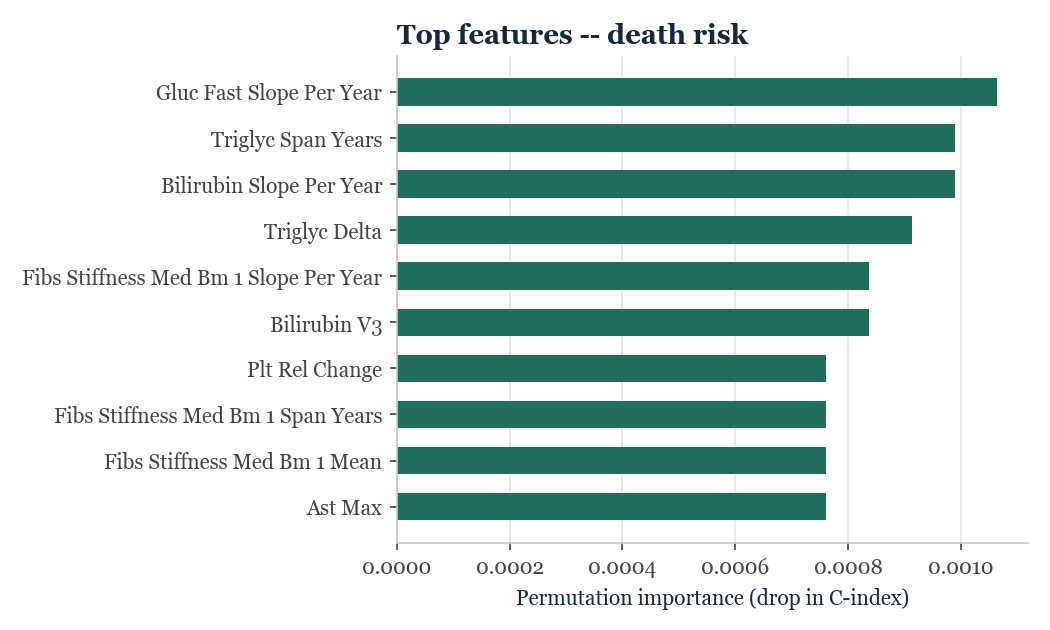

In [10]:
plot_importance(top_death, "Top features -- death risk", IMAGES_DIR / "feature_importance_death.png")
print("Top 5 death:", top_death[:5])


### Kaplan-Meier curves

Computed from the (event, time) pair that `prepare_survival_target` produces on the raw training cohort, so these curves use the exact same event and censoring logic the models were trained on rather than a separate reimplementation.

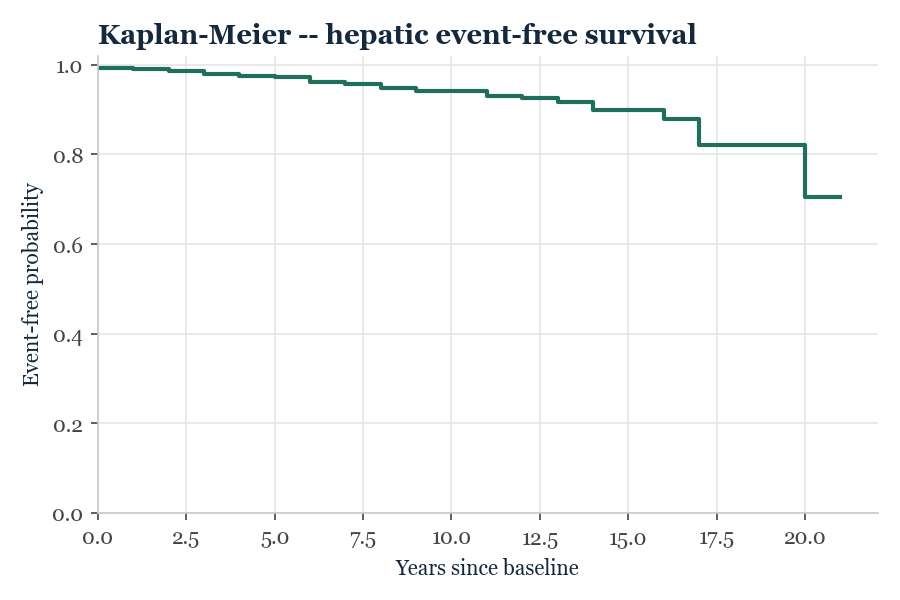

In [11]:
train_raw_df = pd.read_csv(REPO_ROOT / "liverrisk" / "data" / "raw" / "train.csv")

_, _, hep_event_all, hep_time_all = prepare_survival_target(train_raw_df, "hepatic")
_, _, death_event_all, death_time_all = prepare_survival_target(train_raw_df, "death")

hep_km_time, hep_km_surv = kaplan_meier_estimator(hep_event_all, hep_time_all)
death_km_time, death_km_surv = kaplan_meier_estimator(death_event_all, death_time_all)


def plot_km(times, surv, title, out_path):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.step(times, surv, where="post", color=ACCENT, linewidth=2)
    ax.set_ylim(0, 1.02)
    ax.set_xlim(left=0)
    ax.set_xlabel("Years since baseline")
    ax.set_ylabel("Event-free probability")
    ax.set_title(title, fontsize=13, fontweight="bold", loc="left", color=INK)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, transparent=True)
    plt.show()


plot_km(hep_km_time, hep_km_surv, "Kaplan-Meier -- hepatic event-free survival", IMAGES_DIR / "km_curve_hepatic.png")


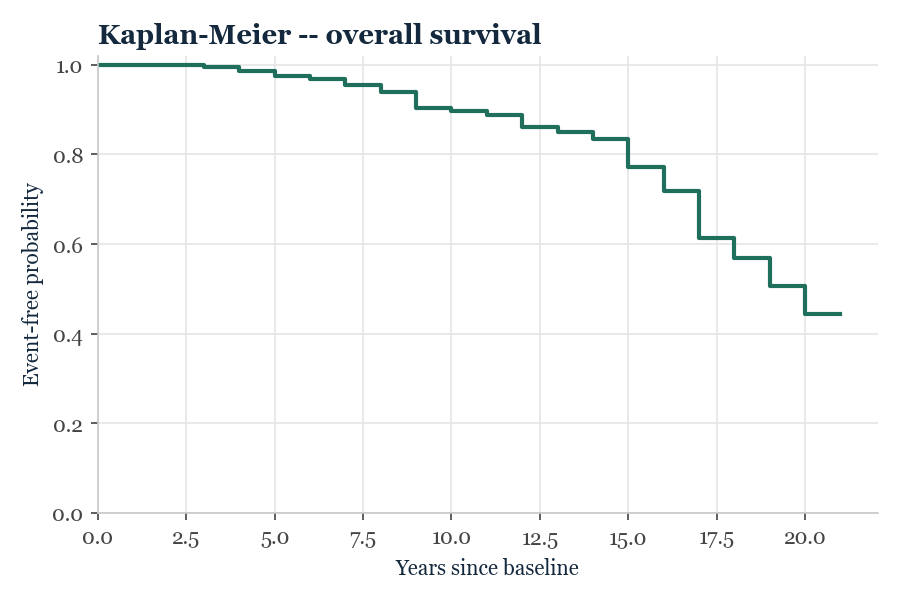

In [12]:
plot_km(death_km_time, death_km_surv, "Kaplan-Meier -- overall survival", IMAGES_DIR / "km_curve_death.png")


### Dataset stats to `about_stats.json`

Writes out a plain set of key value pairs that the webapp displays as is through the GET /about endpoint, with no computation happening on the backend side. `weighted_cindex` is hardcoded from Study 1's verified `n_repeats=3` run rather than recomputed here.

In [13]:
age_cols = [c for c in train_raw_df.columns if re.fullmatch(r"Age_v\d+", c)]
visit_counts = train_raw_df[age_cols].notna().sum(axis=1)

n_patients = len(train_raw_df)
hep_events = int(train_raw_df["evenements_hepatiques_majeurs"].sum())
deaths = int((train_raw_df["death"] == 1).sum())

WEIGHTED_CINDEX = 0.849  # Study 1's verified n_repeats=3 run (see COMPETITION_ANALYSIS.md)

about_stats = {
    "n_patients": n_patients,
    "median_visits": float(visit_counts.median()),
    "min_visits": int(visit_counts.min()),
    "max_visits": int(visit_counts.max()),
    "hepatic_event_count": hep_events,
    "hepatic_event_rate_pct": round(100 * hep_events / n_patients, 1),
    "death_count": deaths,
    "death_rate_pct": round(100 * deaths / n_patients, 1),
    "weighted_cindex": WEIGHTED_CINDEX,
}

with open(PRECOMPUTED_DIR / "about_stats.json", "w") as f:
    json.dump(about_stats, f, indent=2)

about_stats


{
  "n_patients": 1253,
  "median_visits": 4.0,
  "min_visits": 1,
  "max_visits": 19,
  "hepatic_event_count": 47,
  "hepatic_event_rate_pct": 3.8,
  "death_count": 76,
  "death_rate_pct": 6.1,
  "weighted_cindex": 0.849
}